In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import nltk

In [4]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [5]:
nltk.downloader.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...


True

In [6]:
file="FcaebookPosts.xlsx"

In [7]:
xl=pd.ExcelFile(file)

In [8]:
dfs=xl.parse(xl.sheet_names[0])

In [10]:
print(dfs.columns)

Index(['Post'], dtype='object')


In [11]:
print(dfs)

                              Post
0      I really enjoyed this event
1     This is an excellent service
2      The program was very useful
3  I am happy with this experience
4          The service was amazing
5   This was a terrible experience
6      I did not like this service
7               The event was okay


In [15]:
dfs = list(dfs['Post'])

In [16]:
sid=SentimentIntensityAnalyzer()

In [17]:
for data in dfs:
  ss=sid.polarity_scores(data)
  print(data)
  for k in ss:
    print(k,ss[k])

I really enjoyed this event
neg 0.0
neu 0.455
pos 0.545
compound 0.5563
This is an excellent service
neg 0.0
neu 0.519
pos 0.481
compound 0.5719
The program was very useful
neg 0.0
neu 0.556
pos 0.444
compound 0.4927
I am happy with this experience
neg 0.0
neu 0.519
pos 0.481
compound 0.5719
The service was amazing
neg 0.0
neu 0.441
pos 0.559
compound 0.5859
This was a terrible experience
neg 0.508
neu 0.492
pos 0.0
compound -0.4767
I did not like this service
neg 0.345
neu 0.655
pos 0.0
compound -0.2755
The event was okay
neg 0.0
neu 0.612
pos 0.388
compound 0.2263


In [18]:
for data in dfs:
    score = sid.polarity_scores(data)

    if score['compound'] >= 0.05:
        sentiment = "Positive"
    elif score['compound'] <= -0.05:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"

    print(data, "->", sentiment)

I really enjoyed this event -> Positive
This is an excellent service -> Positive
The program was very useful -> Positive
I am happy with this experience -> Positive
The service was amazing -> Positive
This was a terrible experience -> Negative
I did not like this service -> Negative
The event was okay -> Positive


In [19]:
positive = 0
negative = 0
neutral = 0

for data in dfs:
    score = sid.polarity_scores(data)

    if score['compound'] >= 0.05:
        positive += 1
    elif score['compound'] <= -0.05:
        negative += 1
    else:
        neutral += 1

print("Positive:", positive)
print("Negative:", negative)
print("Neutral:", neutral)

Positive: 6
Negative: 2
Neutral: 0


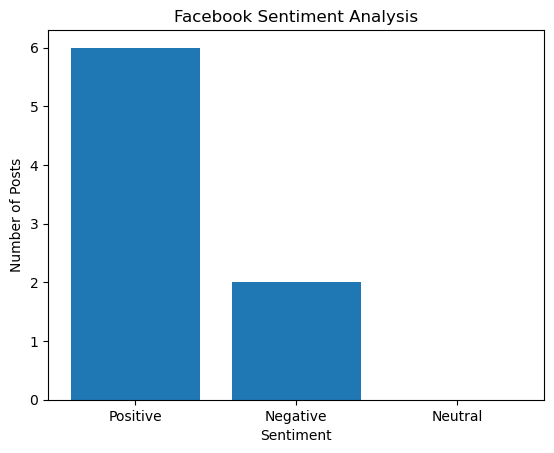

In [20]:
import matplotlib.pyplot as plt

labels = ['Positive', 'Negative', 'Neutral']
values = [positive, negative, neutral]

plt.bar(labels, values)
plt.xlabel('Sentiment')
plt.ylabel('Number of Posts')
plt.title('Facebook Sentiment Analysis')
plt.show()